In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

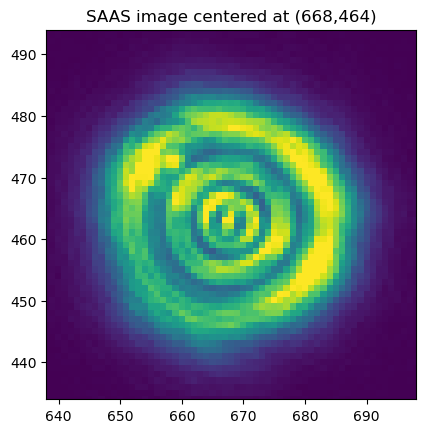

In [ ]:
date = '07-08-25'
directory = os.path.join(os.path.dirname(os.getcwd()), 'images', 'SAAS', date)

saas_data = []

for filename in sorted(os.listdir(directory)):
    if filename == '.DS_Store' or filename[-3:] == 'txt':
        continue
    saas_data.append()
    file_path = os.path.join(directory, filename)
    data = fits.open(file_path)
    fig, ax = plt.subplots()
    im = ax.imshow(data[1].data)

    size = 30
    ax.set_xlim(data[0].header['CROSSHAIR_X']-size,data[0].header['CROSSHAIR_X']+size)
    ax.set_ylim(data[0].header['CROSSHAIR_Y']-size,data[0].header['CROSSHAIR_Y']+size)

    ax.set_title(rf'SAAS image centered at ({data[0].header['CROSSHAIR_X']},{data[0].header['CROSSHAIR_Y']})')

    break

In [37]:
sorted(os.listdir(directory))[-1][-3:]=='txt'

True

In [ ]:
# create plot
fig, ax = plt.subplots()

# plot initial plot
init = np.rot90(map_mag_cor[0].data, k=2)
data = init.data
im = ax.imshow(data, origin='lower', cmap='gray', interpolation='nearest', norm=norm,extent=[x_min, x_max, y_min, y_max])

# format the axes to add the "
def format_ticks(x, pos):
    return f"{x:.0f}\""  # or use .1f for one decimal

# Update function for animation
def update(frame):
    # get the corrected magnetogram and rotate
    m = map_mag_cor[frame % len(map_mag_cor)]
    data = np.rot90(m.data, k=2)
    im.set_data(data)

    # format the axes
    ax.xaxis.set_major_formatter(plt.FuncFormatter(format_ticks))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(format_ticks))
    # this will get the adjusted center with time
    center_x, center_y = get_center_coord(m.date)
    # center around the point of interest
    ax.set_xlim([center_x-450,center_x+450])
    ax.set_ylim([center_y-450,center_y+450])
    ax.set_title(f"Corrected Magnetogram {m.date.value}")
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")
    return [im]

# Create animation
ani = animation.FuncAnimation(
    fig, update,
    frames=len(map_mag_cor),
    interval=200,  # milliseconds per frame
    blit=False
)

# Display in notebook
# HTML(ani.to_jshtml())
ani.save("magnetogram.mp4", writer="ffmpeg", dpi=150)

HERITAGE

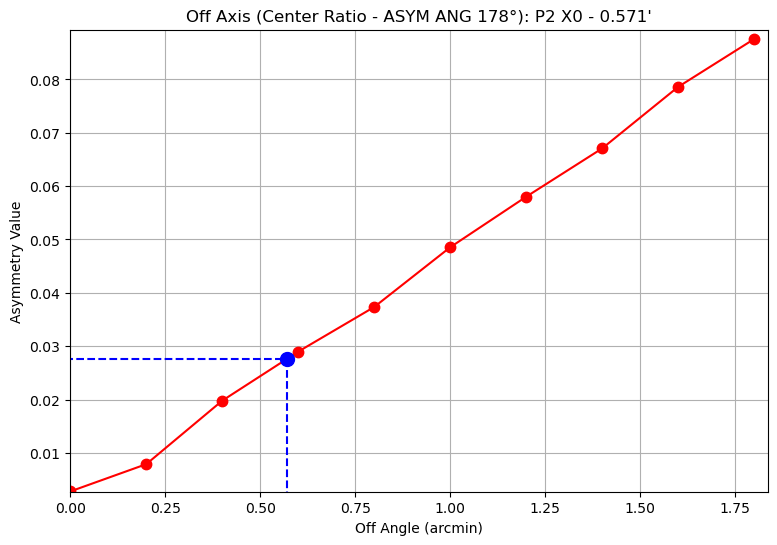

In [30]:
data_offaxis = 0.02765183050852103
ang_offaxis = 178.44430364815406

sim_offaxis = np.array([0.0027690215065726926,0.007877376529590108,0.0197810098870243,0.028975685402093,0.037342640308786555,0.04853892731379359,0.05801128173282485,0.0670718096141247,0.07860331508118105,0.08757239767630685])
sim_angles = np.array([0,0.2,0.4,0.6,0.8,1.0,1.2,1.4,1.6,1.8])
lab_offaxis  = 'Center Ratio'

pos = 2
xmod = 0

offangle = np.interp(data_offaxis,sim_offaxis,sim_angles)

plt.figure(figsize=(9,6))
plt.plot(sim_angles,sim_offaxis,'r.-',markersize=15)
plt.plot([-1,offangle],[data_offaxis,data_offaxis],'b--')
plt.plot([offangle,offangle],[data_offaxis,sim_offaxis[0]*.98],'b--')
plt.plot(offangle,data_offaxis,'b.',markersize=20)
plt.xlim([sim_angles[0]*.98,sim_angles[-1]*1.02])
plt.ylim([sim_offaxis[0]*.98,sim_offaxis[-1]*1.02])
#plt.xlim([sim_angles[0]*.98,1.9])
#plt.ylim([sim_offaxis[0]*.98,.105])
#plt.xlim(10.5,13.0)
#plt.ylim(.3,.4)
plt.grid()
plt.xlabel('Off Angle (arcmin)')
plt.ylabel('Asymmetry Value')
plt.title("Off Axis ("+lab_offaxis+" - ASYM ANG {:.0f}°".format(ang_offaxis)+"): P"+str(pos)+ " X"+str(xmod)+ " - {:.3f}\'".format(offangle))
plt.show()

NAGOYA P4 (third ring blue and fourth ring black)

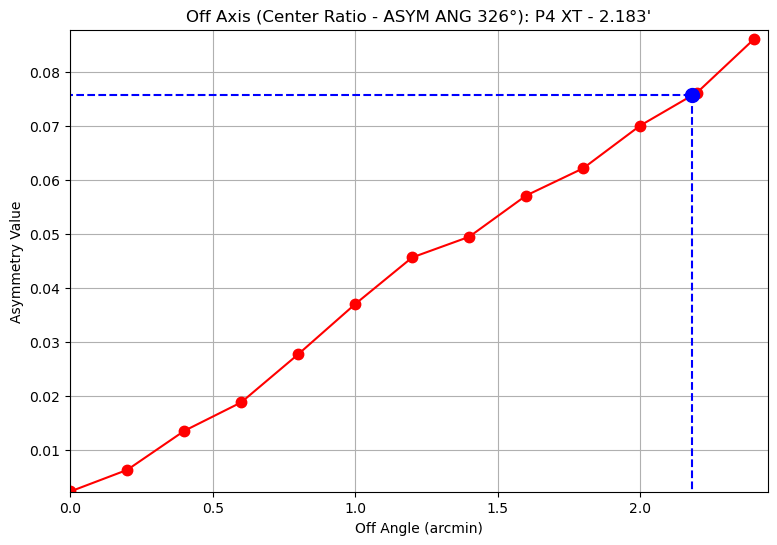

In [60]:
data_offaxis = 0.07565623464145546
ang_offaxis = 326.125966495004

sim_offaxis = np.array([0.002302814071808097,0.006307647452839266,0.013525336943173675,0.018808056797001146,0.02771535173744797,0.03700882102165545,0.04564378861488459,0.04946726410965102,0.057110966006714156,0.06215017330032551,0.07005142923744032,0.07618658186775125,0.08609349467856252])
sim_angles = np.array([0,0.2,0.4,0.6,0.8,1.0,1.2,1.4,1.6,1.8,2.0,2.2,2.4])
lab_offaxis  = 'Center Ratio'

pos = 4
xmod = 'T'

offangle = np.interp(data_offaxis,sim_offaxis,sim_angles)

plt.figure(figsize=(9,6))
plt.plot(sim_angles,sim_offaxis,'r.-',markersize=15)
plt.plot([-1,offangle],[data_offaxis,data_offaxis],'b--')
plt.plot([offangle,offangle],[data_offaxis,sim_offaxis[0]*.98],'b--')
plt.plot(offangle,data_offaxis,'b.',markersize=20)
plt.xlim([sim_angles[0]*.98,sim_angles[-1]*1.02])
plt.ylim([sim_offaxis[0]*.98,sim_offaxis[-1]*1.02])
# plt.xlim([sim_angles[0]*.98,1.9])
# plt.ylim([sim_offaxis[0]*.98,.105])
#plt.xlim(10.5,13.0)
#plt.ylim(.3,.4)
plt.grid()
plt.xlabel('Off Angle (arcmin)')
plt.ylabel('Asymmetry Value')
plt.title("Off Axis ("+lab_offaxis+" - ASYM ANG {:.0f}°".format(ang_offaxis)+"): P"+str(pos)+ " X"+str(xmod)+ " - {:.3f}\'".format(offangle))
plt.show()

In [41]:
np.arange(5,6,.1)

array([5. , 5.1, 5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9])

NAGOYA P4 (first ring green and third ring blue)

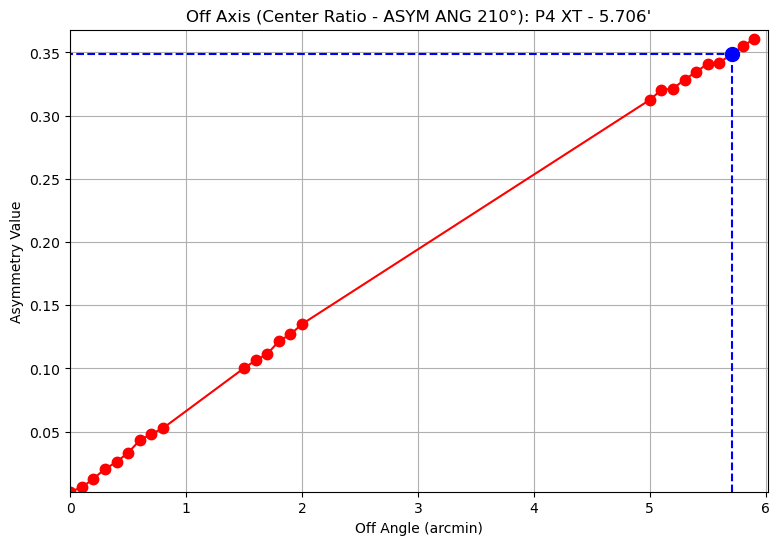

In [42]:
data_offaxis =  0.3487315385224618
ang_offaxis = 210.24169692775783

sim_offaxis = np.array([0.002481307771259484,0.00586839050558356,0.012791011512446371,0.02044056639960852,0.02608120242417312,
                        0.03336588140079821,0.04317026510694239,0.04808675146497335,0.05272132163973283,
                        0.10027967282319443,0.10643504935787741,0.11142236149488755,0.12160593769396982,0.1270224093963938,0.1351252355344975,
                        0.31249767174459353,0.32036056327422663,0.3213084598180149,0.3285563254839548,0.3347117688369706,
                        0.34105629000070975,0.34186769458804106,0.34832268513783665,0.3548095607238569,0.3607851301120777])
sim_angles = np.array([0.0,0.1,0.2,0.3,0.4,
                       0.5,0.6,0.7,0.8,
                       1.5,1.6,1.7,1.8,1.9,2.0,
                       5.0,5.1,5.2,5.3,5.4,
                       5.5,5.6,5.7,5.8,5.9])
lab_offaxis  = 'Center Ratio'

pos = 4
xmod = 'T'

offangle = np.interp(data_offaxis,sim_offaxis,sim_angles)

plt.figure(figsize=(9,6))
plt.plot(sim_angles,sim_offaxis,'r.-',markersize=15)
plt.plot([-1,offangle],[data_offaxis,data_offaxis],'b--')
plt.plot([offangle,offangle],[data_offaxis,sim_offaxis[0]*.98],'b--')
plt.plot(offangle,data_offaxis,'b.',markersize=20)
plt.xlim([sim_angles[0]*.98,sim_angles[-1]*1.02])
plt.ylim([sim_offaxis[0]*.98,sim_offaxis[-1]*1.02])
# plt.xlim([sim_angles[0]*.98,1.9])
# plt.ylim([sim_offaxis[0]*.98,.105])
#plt.xlim(10.5,13.0)
#plt.ylim(.3,.4)
plt.grid()
plt.xlabel('Off Angle (arcmin)')
plt.ylabel('Asymmetry Value')
plt.title("Off Axis ("+lab_offaxis+" - ASYM ANG {:.0f}°".format(ang_offaxis)+"): P"+str(pos)+ " X"+str(xmod)+ " - {:.3f}\'".format(offangle))
plt.show()

NAGOYA P1 (first ring green second ring red)

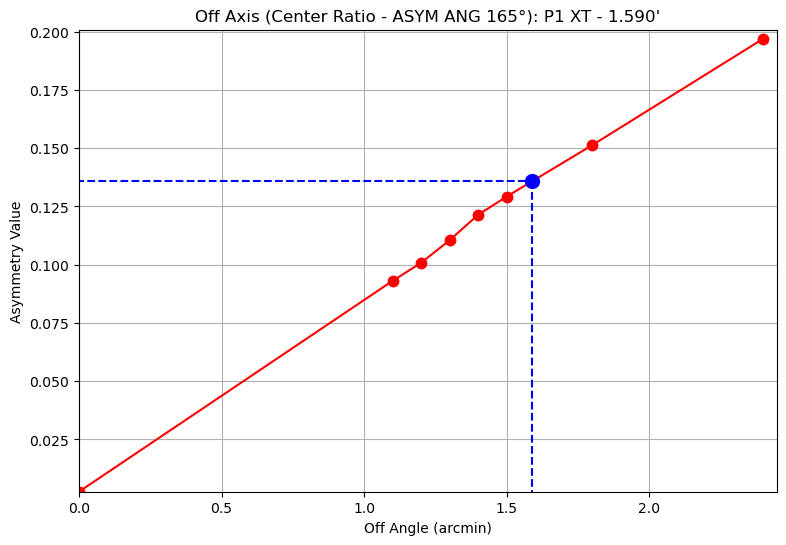

In [ ]:
data_offaxis = 0.13583836493085236
ang_offaxis = 165.45793678925492

sim_offaxis = np.array([0.002637583320418971,0.09306444403910823,0.10082558632974625,0.11048297937124163,0.12140831394938013,0.1292115673055523,0.15126457707190455,0.1969112887218705])
sim_angles = np.array([0,1.1,1.2,1.3,1.4,1.5,1.8,2.4])
lab_offaxis  = 'Center Ratio'

pos = 1
xmod = 'T'

offangle = np.interp(data_offaxis,sim_offaxis,sim_angles)

plt.figure(figsize=(9,6))
plt.plot(sim_angles,sim_offaxis,'r.-',markersize=15)
plt.plot([-1,offangle],[data_offaxis,data_offaxis],'b--')
plt.plot([offangle,offangle],[data_offaxis,sim_offaxis[0]*.98],'b--')
plt.plot(offangle,data_offaxis,'b.',markersize=20)
plt.xlim([sim_angles[0]*.98,sim_angles[-1]*1.02])
plt.ylim([sim_offaxis[0]*.98,sim_offaxis[-1]*1.02])
# plt.xlim([sim_angles[0]*.98,1.9])
# plt.ylim([sim_offaxis[0]*.98,.105])
#plt.xlim(10.5,13.0)
#plt.ylim(.3,.4)
plt.grid()
plt.xlabel('Off Angle (arcmin)')
plt.ylabel('Asymmetry Value')
plt.title("Off Axis ("+lab_offaxis+" - ASYM ANG {:.0f}°".format(ang_offaxis)+"): P"+str(pos)+ " X"+str(xmod)+ " - {:.3f}\'".format(offangle))
plt.show()

Marshall 2 Shell

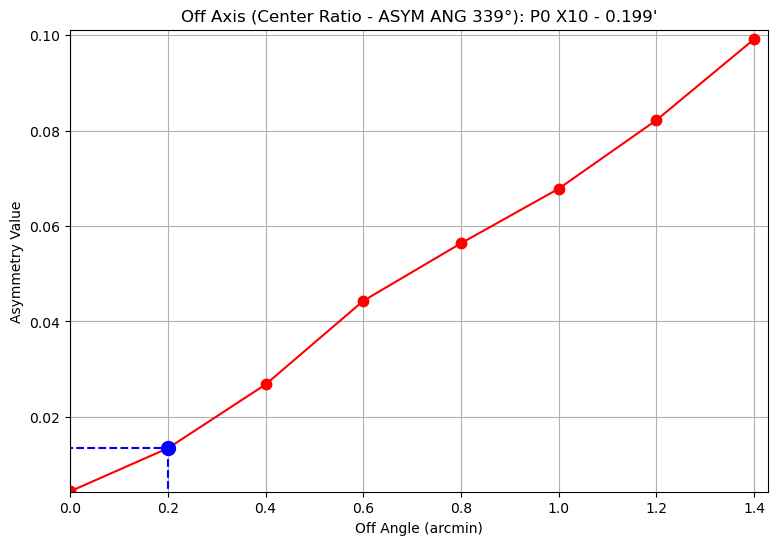

In [28]:
data_offaxis = 0.01340576833453092
ang_offaxis = 338.66669635035765

sim_offaxis = np.array([0.004404829819715174,0.013435962279179257,0.026812345979480515,0.04432791847398074,0.05639705920685293,0.0678383931662594,0.08220290778500289,0.09917082769916032])
sim_angles = np.array([0,0.2,0.4,0.6,0.8,1.0,1.2,1.4])
lab_offaxis  = 'Center Ratio'

pos = 0
xmod = 10

offangle = np.interp(data_offaxis,sim_offaxis,sim_angles)

plt.figure(figsize=(9,6))
plt.plot(sim_angles,sim_offaxis,'r.-',markersize=15)
plt.plot([-1,offangle],[data_offaxis,data_offaxis],'b--')
plt.plot([offangle,offangle],[data_offaxis,sim_offaxis[0]*.98],'b--')
plt.plot(offangle,data_offaxis,'b.',markersize=20)
plt.xlim([sim_angles[0]*.98,sim_angles[-1]*1.02])
plt.ylim([sim_offaxis[0]*.98,sim_offaxis[-1]*1.02])
# plt.xlim([sim_angles[0]*.98,1.9])
# plt.ylim([sim_offaxis[0]*.98,.105])
#plt.xlim(10.5,13.0)
#plt.ylim(.3,.4)
plt.grid()
plt.xlabel('Off Angle (arcmin)')
plt.ylabel('Asymmetry Value')
plt.title("Off Axis ("+lab_offaxis+" - ASYM ANG {:.0f}°".format(ang_offaxis)+"): P"+str(pos)+ " X"+str(xmod)+ " - {:.3f}\'".format(offangle))
plt.show()

In [21]:
from numpy import load

data = load('FOXSI4_Nagoya_ellipse_POS1_RUN1.npz')
lst = data.files
for item in lst:
    print(item)
    print(data[item])

centers
[[1549.78149414 1549.32531738]
 [1556.75976562 1548.6685791 ]
 [1497.03918457 1533.56860352]
 [1509.67431641 1534.41137695]]
axes
[[154.09205627 168.8316803 ]
 [225.51089478 244.55647278]
 [631.48028564 659.2699585 ]
 [767.55505371 819.53936768]]
angles
[ 71.15273285  52.82559204 179.25819397  18.89391136]


In [46]:
sc1 = np.array([0.0,2.8])
sc2 = np.array([np.cos(30.0*np.pi/180.0),np.sin(30.0*np.pi/180.0)])*2.8
sc3 = np.array([np.cos(-30.0*np.pi/180.0),np.sin(-30.0*np.pi/180.0)])*2.8
sc4 = np.array([0.0,-2.8])
sc5 = np.array([np.cos(-150.0*np.pi/180.0),np.sin(-150.0*np.pi/180.0)])*2.8
sc6 = np.array([np.cos(150.0*np.pi/180.0),np.sin(150.0*np.pi/180.0)])*2.8

sc=np.array([sc1,sc2,sc3,sc4,sc5,sc6])

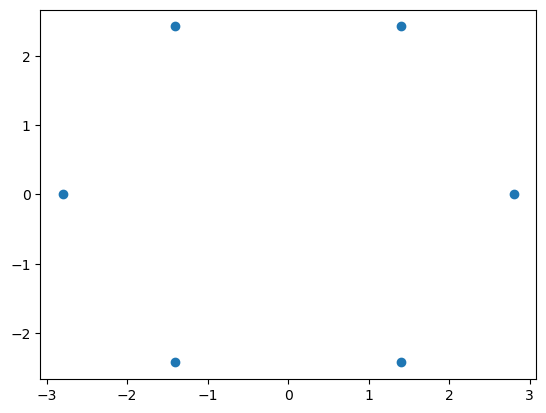

In [52]:
plt.scatter(sc[:,1],sc[:,0])

In [53]:
sc[:,1]

array([ 2.8,  1.4, -1.4, -2.8, -1.4,  1.4])

In [54]:
sc[:,0]

array([ 0.        ,  2.42487113,  2.42487113,  0.        , -2.42487113,
       -2.42487113])